# 08c · GSE65391 · RNA_array · pvclust-py: which gene clusters are supported? (Python)

Reads `hub_matrix_first_visits.csv` and `hub_genes.csv` (written by notebook 07). Writes
`pvclust_genes.pkl` in `data/run_artifacts/GSE65391/` and the dendrogram to `figures/GSE65391/`.

**Method.** Hierarchical clustering with approximately unbiased (AU) p-values from multiscale bootstrap
resampling (Suzuki R, Shimodaira H. Pvclust: an R package for assessing the uncertainty in hierarchical
clustering. *Bioinformatics* 2006;22:1540–1542, doi:10.1093/bioinformatics/btl117; multiscale bootstrap:
Shimodaira H. An approximately unbiased test of phylogenetic tree selection. *Syst Biol* 2002;51:492–508,
doi:10.1080/10635150290069913). A cluster with AU ≥ 0.95 is supported at the 5% level: it would reappear
if another sample of patients were drawn from the same population.

**Implementation.** pvclust-py (NIH-NLM/pvclust-py, pinned in `endotypes-transcriptomics.yml` to commit
6b0c3bf), a line-by-line Python port of R pvclust 2.2-0 checked against R fixtures.

| setting | value | reason |
|---|---|---|
| objects clustered | the 160 hub genes | this notebook asks about gene groups |
| resampling units | the 157 patients (first visits) | pvclust-py documentation: resampling samples to cluster analytes is "the sound direction" |
| distance | `minkowski` (p = 2, Euclidean) | as in the R heatmaps; pvclust's minkowski is always p = 2 |
| linkage | `ward.D2` | as in the R heatmaps |
| bootstrap replicates | 1,000 per scale | R pvclust's default |
| scales r | 0.5 to 1.4 by 0.1 | R pvclust's default |
| seed | 20260928 | the project seed |

**No k.** The tree is not cut at a number of groups. `pvpick` (α = 0.95, largest non-overlapping
clusters first) returns the clusters that clear the AU threshold.

**Test.** Each significant gene cluster against the WGCNA modules: does it hold the hub genes of one
module, or mix modules?

In [1]:
import pickle, collections
from pathlib import Path
import pandas as pd
from IPython.display import Image, display
from pvclust_py.core import pvclust, pvpick
from pvclust_py.plot import dendrogram

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "endotypes-transcriptomics.yml").exists())
ART  = ROOT / "data" / "run_artifacts" / "GSE65391"
FIG  = ROOT / "figures" / "GSE65391"; FIG.mkdir(parents=True, exist_ok=True)
SEED = 20260928
pd.set_option("display.max_colwidth", None)   # show every cluster member

X     = pd.read_csv(ART / "hub_matrix_first_visits.csv", index_col=0)     # patients x genes
genes = pd.read_csv(ART / "hub_genes.csv").set_index("gene")["module"]
X.shape

(157, 160)

In [2]:
res = pvclust(X, cluster="columns", method_dist="minkowski", method_hclust="ward.D2",
              nboot=1000, seed=SEED)
edges = res.edges_frame()
edges[["size", "au", "bp"]].describe() if "size" in edges else edges[["au", "bp"]].describe()

,au,bp
count,159.000000,159.000000
mean,0.831471,0.538524
std,0.134531,0.299171
min,0.457838,0.027014
25%,0.727958,0.253343
50%,0.855499,0.498623
75%,0.955573,0.794286
max,1.000000,1.000000


In [3]:
picked = pvpick(res, alpha=0.95)
rows = []
for e in picked:
    mods = collections.Counter(genes[m] for m in e["members"])
    rows.append({"genes": len(e["members"]), "AU": round(e["au"], 3), "BP": round(e["bp"], 3),
                 "modules": ", ".join(f"{k} ({v})" for k, v in mods.most_common())})
table = pd.DataFrame(rows).sort_values("genes", ascending=False).reset_index(drop=True)
print(f"{len(picked)} significant gene clusters (AU >= 0.95)")
table

14 significant gene clusters (AU >= 0.95)


,genes,AU,BP,modules
0,30,0.964,0.467,"cyan (10), turquoise (10), black (10)"
1,10,1.000,1.000,green (10)
2,10,1.000,1.000,lightcyan (10)
3,10,1.000,1.000,blue (10)
4,10,1.000,1.000,yellow (10)
5,10,1.000,1.000,pink (10)
6,10,1.000,1.000,brown (10)
7,10,1.000,0.998,salmon (10)
8,10,1.000,1.000,greenyellow (10)
9,10,0.994,0.996,red (10)


**Test.** How many significant clusters hold the hub genes of a single module only, and how many of the
16 modules are exactly one significant cluster (all 10 hub genes, nothing else)?

In [4]:
single = sum(1 for e in picked if len({genes[m] for m in e["members"]}) == 1)
exact  = sum(1 for mo in genes.unique()
             if any(set(e["members"]) == set(genes.index[genes == mo]) for e in picked))
print(f"significant clusters from a single module: {single} of {len(picked)}")
print(f"modules recovered exactly as one significant cluster: {exact} of {genes.nunique()}")

significant clusters from a single module: 13 of 14
modules recovered exactly as one significant cluster: 13 of 16


**Result.** 14 gene clusters with AU ≥ 0.95. 13 of the 16 WGCNA modules come back exactly as one
significant cluster (all 10 hub genes, nothing else): 11 at AU = 1.000, red at 0.994 and midnightblue at
0.985, all 13 with BP ≥ 0.996. Pink (interferon): AU = 1.000, BP = 1.000. The fourteenth cluster joins
three modules, cyan (B cell), turquoise and black: AU = 0.964, BP = 0.467.

AU is the approximately unbiased p-value from the multiscale bootstrap; BP is the ordinary bootstrap probability, which is biased (Suzuki and Shimodaira 2006). A cluster with high AU and low BP is supported only after the multiscale correction.


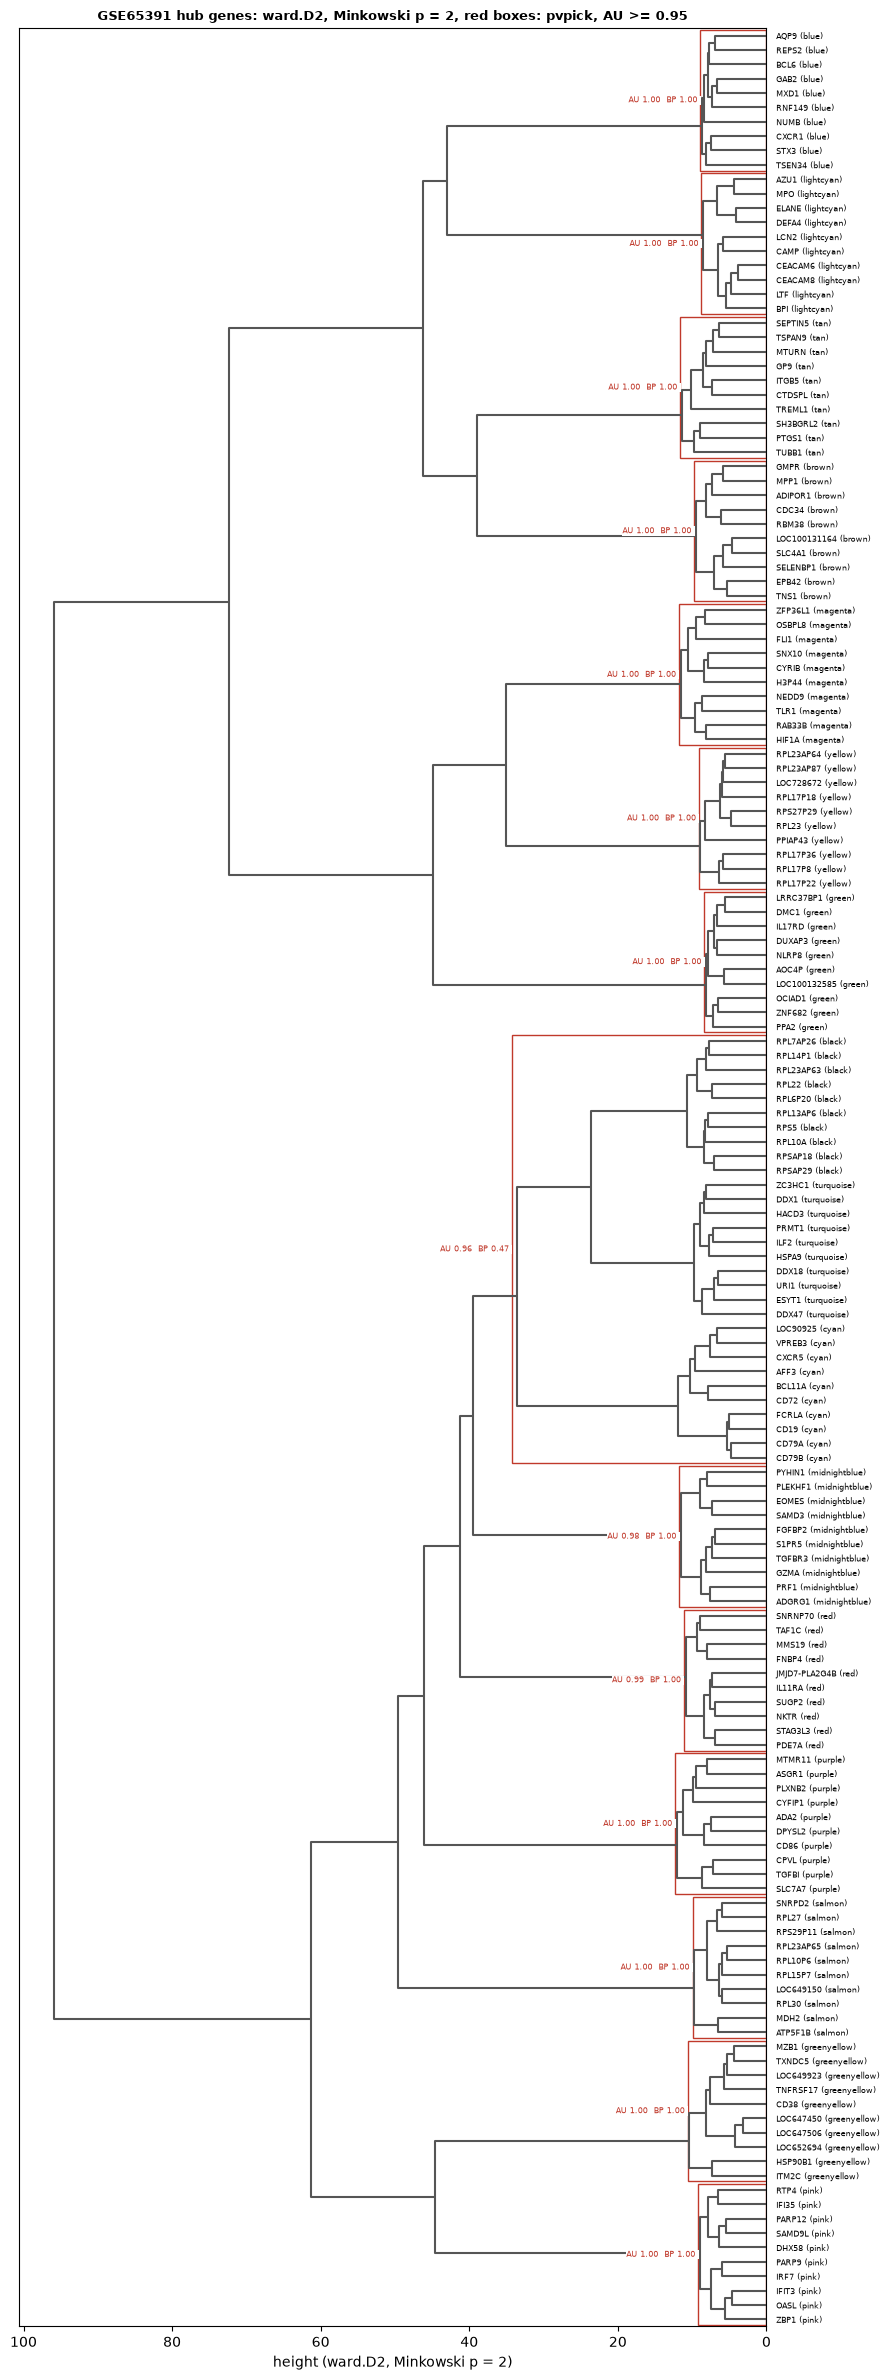

In [5]:
# The pvclust tree with every label shown. Each red box is one pvpick cluster (AU >= 0.95),
# labelled with its AU and BP values (AU: approximately unbiased; BP: ordinary bootstrap).
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.cluster.hierarchy import dendrogram as tree

def pv_figure(res, picked, leaf_text, title, path):
    n = len(res.labels)
    fig, ax = plt.subplots(figsize=(9, max(4, 0.14 * n + 1.5)))
    d = tree(res.linkage, labels=[leaf_text[l] for l in res.labels], orientation="left", ax=ax,
             color_threshold=0, above_threshold_color="#555555", leaf_font_size=6)
    pos = {res.labels[j]: 5 + 10 * k for k, j in enumerate(d["leaves"])}
    for e in picked:
        ys = [pos[m] for m in e["members"]]
        h = res.linkage[e["merge_order"] - 1, 2] * 1.02
        ax.add_patch(Rectangle((0, min(ys) - 4), h, max(ys) - min(ys) + 8, fill=False, edgecolor="#C0392B", lw=1))
        ax.text(h, (min(ys) + max(ys)) / 2, f"AU {e['au']:.2f}  BP {e['bp']:.2f} ", color="#C0392B",
                fontsize=6, ha="right", va="center",
                bbox=dict(facecolor="white", edgecolor="none", pad=0.3))
    ax.set_xlabel("height (ward.D2, Minkowski p = 2)")
    ax.set_title(title, fontsize=9, fontweight="bold")
    fig.tight_layout()
    fig.savefig(path, dpi=300)
    plt.show()

leaf_text = {g: f"{g} ({genes[g]})" for g in res.labels}
pv_figure(res, picked, leaf_text, "GSE65391 hub genes: ward.D2, Minkowski p = 2, red boxes: pvpick, AU >= 0.95", FIG / "08c_GSE65391_RNA_array_pvclust_genes.png")


In [6]:
pickle.dump(res, open(ART / "pvclust_genes.pkl", "wb"))